In [ ]:
import keras
import tensorflow as tf
import numpy as np
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt
try:
  from netCDF4 import Dataset
except:
  !pip install netCDF4
  from netCDF4 import Dataset
import datetime as dt
try:
  import cartopy.crs as ccrs
except:
  !pip install cartopy
  import cartopy.crs as ccrs
from joblib import Parallel, delayed


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.9 MB/s eta 0:00:00


### Download Data
- This takes very long so recommend that you just use the zenodo link directly

In [ ]:
!wget https://zenodo.org/records/20159662/files/collocated_dataset.nc?download=1
!wget https://zenodo.org/records/20159662/files/BHIST.f09_g17.coupled_nature.cam.h1.201001-201012.nc?download=1
!wget https://zenodo.org/records/20159662/files/domain.lnd.fv0.9x1.25_gx1v7.151020.nc?download=1

--2026-05-13 15:01:32--  https://zenodo.org/records/20159662/files/collocated_dataset.nc?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3928247285 (3.7G) [application/octet-stream]
Saving to: ‘collocated_dataset.nc?download=1’

     collocated_dat   0%[                    ]  15.22M   523KB/s    eta 2h 14m ^C
--2026-05-13 15:02:32--  https://zenodo.org/records/20159662/files/BHIST.f09_g17.coupled_nature.cam.h1.201001-201012.nc?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
^C
--2026-05-13 15:02:33--  https://zenodo.org/records/20159662/files/domain.lnd.fv0.9x1.25_gx1v7.151020.nc?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 137.138.153.219, 188.185.43.153, ...
Connect

In [ ]:
nc_domain = Dataset('domain.lnd.fv0.9x1.25_gx1v7.151020.nc')
lon = np.array(nc_domain['xc'][:])
lat = np.array(nc_domain['yc'][:])

In [ ]:
nc = Dataset('collocated_dataset.nc')
time = np.array(nc['YYYYMMDDHH'][:])
cldliq = np.array(nc['CLDLIQ'][:])
cldice = np.array(nc['CLDICE'][:])
swndr = np.array(nc['a2x1hi_Faxa_swndr'][:])
swvdr = np.array(nc['a2x1hi_Faxa_swvdr'][:])
swndf = np.array(nc['a2x1hi_Faxa_swndf'][:])
swvdf = np.array(nc['a2x1hi_Faxa_swvdf'][:])

In [ ]:
nc_sza = Dataset('BHIST.f09_g17.coupled_nature.cam.h1.201001-201012.nc')
date_sza = np.array(nc_sza['date'][:])
datesec_sza = np.array(nc_sza['datesec'][:])
time_sza = []
for i in range(date_sza.shape[0]):
    month = int(str(date_sza[i])[4:6])
    day = int(str(date_sza[i])[6:])
    hour = int(datesec_sza[i]/3600)
    time_sza.append('2011-{:02d}-{:02d}-{:02d}'.format(month, day, hour))
time_sza = np.array(time_sza)

C:\Users\josep\AppData\Local\Temp\ipykernel_13052\3252438597.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.pcolormesh(lon, lat, np.log10(swndf[0, index_time, :, :]), transform = ccrs.PlateCarree())


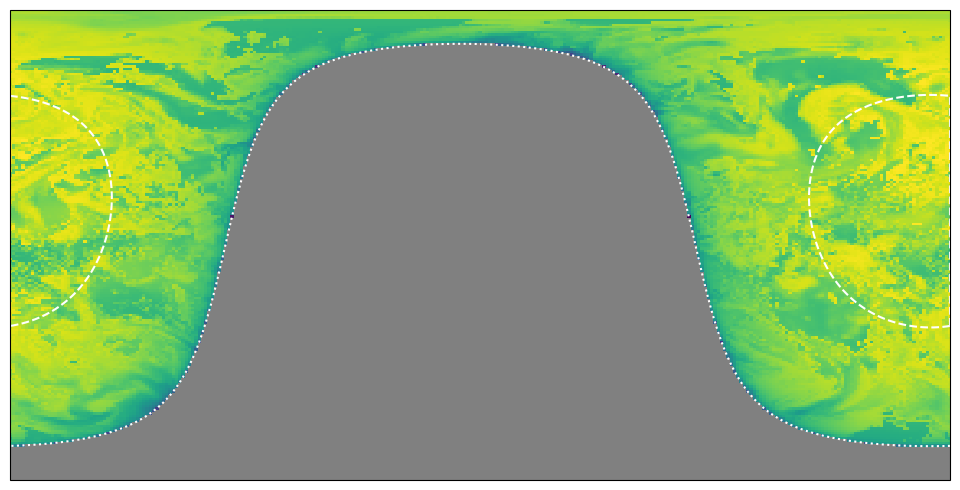

In [ ]:
sza = np.zeros((time.shape[0], 192, 288))
for i in range(time.shape[0]):
    idt = np.where(time_sza == time[i])[0][0]
    sza1 = np.array(nc_sza['SZA'][idt, :, :])
    sza2 = np.array(nc_sza['SZA'][idt+1, :, :])
    sza[i, :, :] = (sza1 + sza2) * 0.5

index_time = 20
fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_facecolor('gray')
ax.pcolormesh(lon, lat, np.log10(swndf[0, index_time, :, :]), transform = ccrs.PlateCarree())
ax.contour(lon, lat, sza[index_time, :, :], levels = [0, 45, 90], linestyles = ['-', '--', ':'], colors = ['white'], transform = ccrs.PlateCarree())

In [ ]:
index_time = 0

for i in range(10):
    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swndr[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swndr_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swvdr[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swvdr_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swndf[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swndf_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swvdf[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swvdf_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_facecolor('gray')
im = ax.pcolormesh(lon, lat, sza[index_time, :, :], cmap = 'viridis', vmin = 0, transform = ccrs.PlateCarree())
cs = ax.contour(lon, lat, sza[index_time, :, :], levels = [0, 30, 60, 90], linestyles = ['--', '-.', ':',  '-'], colors = ['white'], transform = ccrs.PlateCarree())
ax.clabel(cs, levels = [0, 30, 60, 90], inline = True)
cbar = plt.colorbar(im, shrink = 0.7)
fig.savefig('sza.png'.format(i+1), bbox_inches = 'tight')

### Process data into train/test set

In [ ]:
idx_valid = np.where(sza < 90, True, False) * np.where(np.std(swndr, axis = 0) > 1e-2, True, False) * np.where(np.std(swvdr, axis = 0) > 1e-2, True, False) * np.where(np.std(swndf, axis = 0) > 1e-2, True, False) * np.where(np.std(swvdf, axis = 0) > 1e-2, True, False)
n_sample = np.count_nonzero(idx_valid)
print(n_sample)

swndr_valid = swndr[:, idx_valid]
swvdr_valid = swvdr[:, idx_valid]
swndf_valid = swndf[:, idx_valid]
swvdf_valid = swvdf[:, idx_valid]
sw_valid = np.stack((swndr_valid, swvdr_valid, swndf_valid, swvdf_valid), axis = 0)

def task_cov(idx, data, eps = 1e-6):
    '''
    Compute square-root of covariance matrix
    COV = U @ S^0.5 @ S^0.5 @ U.T
    U: singular vectors
    S: singular values
    data: [n_variable, n_ensemble, n_sample]
    label: [4 square-root of singular values, 16 elements of the U matrix matrix]
    '''
    cov = np.cov(data[:, :, idx], ddof = 1) + eps * np.eye(data.shape[0])
    u, s, _ = scipy.linalg.svd(cov)
    return np.concatenate((np.sqrt(s), u.flatten()), axis = 0), idx


Y = np.zeros((n_sample, 20))
results = Parallel(n_jobs = 10)(
    delayed(task_cov)(i, sw_valid) for i in range(n_sample)
)
for label, idx in results:
    Y[idx, :] = label

1926983


In [ ]:
sw_mean = np.mean(sw_valid, axis = 1)
sza_valid = sza[idx_valid]
X = np.concatenate((sw_mean.T, sza_valid.reshape(-1, 1)), axis = -1)
print(X.shape)

(1926983, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

'''
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)
'''

(1348888, 5)
(578095, 5)
(1348888, 20)


'\nscaler_Y = StandardScaler()\nY_train_scaled = scaler_Y.fit_transform(Y_train)\nY_test_scaled = scaler_Y.transform(Y_test)\n'

### Define the model

In [ ]:
def orthogonal_process_layer(raw_output):
    # 1. Slice the tensor (Assuming shape is [Batch, 20])
    s_raw = raw_output[:, :4]   # First 4: Log of sqrt singular values (assumed)
    u_raw = raw_output[:, 4:]   # Last 16: Raw matrix elements

    # 2. Constrain Singular Values to be positive
    # Using exp assumes the network is predicting log(sqrt singular values)
    s_constrained = tf.exp(s_raw)

    # 3. Orthogonalize the Vector elements
    # Reshape 16 elements to a 4x4 matrix
    u_matrix = tf.reshape(u_raw, [-1, 4, 4])

    # Apply QR
    q, r = tf.linalg.qr(u_matrix)

    # Fix sign ambiguity using the diagonal of R
    diag_r = tf.linalg.diag_part(r)
    sign_corrector = tf.sign(diag_r)[:, tf.newaxis, :]
    u_orthogonal_matrix = q * sign_corrector

    # Flatten back to 16 elements
    u_flat = tf.reshape(u_orthogonal_matrix, [-1, 16])

    # 4. Merge back to a 20-element vector
    combined = tf.concat([s_constrained, u_flat], axis=1)

    return combined


In [ ]:
model = keras.Sequential()
model.add(keras.Input(shape = (5, )))
model.add(keras.layers.Dense(units = 50, activation=keras.activations.leaky_relu))
model.add(keras.layers.Dense(units = 100, activation=keras.activations.leaky_relu))
model.add(keras.layers.Dense(units = 100, activation=keras.activations.leaky_relu))
model.add(keras.layers.Dense(units = 50, activation=keras.activations.leaky_relu))
model.add(keras.layers.Dense(units = 20, activation = keras.activations.linear))
model.add(keras.layers.Lambda(orthogonal_process_layer))

In [ ]:
def vec_to_us(vec, k=4):
    '''
    vec: [batch_size, output_size]
    '''
    batch_size = tf.shape(vec)[0]
    s = vec[:, :4]**2
    u = tf.reshape(vec[:, 4:], (batch_size, k, k))
    return u, s


def kl_divergence(u1, s1, u2, s2, k = 4):
    """
    KL divergence D_KL(N(0, Σ1) || N(0, Σ2))
    where Σ1 = (u1 @ s1^0.5) @ (u1 @ s1^0.5).T and Σ2 = (u2 @ s2^0.5) @ (u2 @ s2^0.5).T

    Args:
        u1, u2: [batch, k, k] singular vector matrix
        s1, s2: [batch, k] singular values

    Returns:
        KL divergence per batch: [batch]
    """

    # Log determinant: Determinants are simply product of singular values
    logdet1 = tf.math.log(tf.reduce_prod(s1, axis = -1))
    logdet2 = tf.math.log(tf.reduce_prod(s2, axis = -1))
    logdet_term = logdet2 - logdet1

    # Trace term: easy to compute inverse since we know orthogonal transformation
    S2_i = (u2 * 1/s2[:, None, :]) @ tf.transpose(u2, perm = [0, 2, 1])
    S1 = (u1 * s1[:, None, :]) @ tf.transpose(u1, perm = [0, 2, 1])
    trace_term = tf.linalg.trace(S2_i @ S1)

    kl = 0.5 * (trace_term - k + logdet_term)

    return kl

def kl_loss(y_true, y_pred):
    u1, s1 = vec_to_us(y_true)
    u2, s2 = vec_to_us(y_pred)
    kl = kl_divergence(u1, s1, u2, s2)
    return tf.reduce_mean(kl)


In [ ]:
k = 4
batch = 10

vec_size = 20

y_true = tf.convert_to_tensor(Y_train[0:10, :])
y_pred = tf.convert_to_tensor(Y_train[100:110, :])

u1, s1 = vec_to_us(y_true)
u2, s2 = vec_to_us(y_pred)

# Log determinant: Determinants are simply product of singular values
logdet1 = tf.math.log(tf.reduce_prod(s1, axis = -1))
logdet2 = tf.math.log(tf.reduce_prod(s2, axis = -1))
logdet_term = logdet2 - logdet1
print(logdet_term.numpy())

# Trace term: easy to compute inverse since we know orthogonal transformation
S2_i = (u2 * 1/s2[:, None, :]) @ tf.transpose(u2, perm = [0, 2, 1])
S1 = (u1 * s1[:, None, :]) @ tf.transpose(u1, perm = [0, 2, 1])
trace_term = tf.linalg.trace(S2_i @ S1)

kl = 0.5 * (trace_term - k + logdet_term)
print(kl.numpy())

loss_fn = kl_loss(y_true, y_pred)
print(loss_fn.numpy())

[-25.46113432  26.53074236  -2.94726992  -4.14076145   5.24632451
   1.72259826 -22.50773453 -10.96810473  -6.6369672  -18.43638185]
[6.34652812e+04 1.12817589e+01 7.57973526e+00 4.52666487e+01
 7.30035662e+00 2.51491709e+01 1.39154862e+05 5.32228437e+01
 4.14008361e+02 5.89321206e+03]
20907.716369727343


In [ ]:
# Adjustable Learning Rate Callback
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', factor = 0.9, patience = 5, min_lr = 0.00001, verbose = 1)
# Model Checkpoint Callback - Save Model when validation loss hits mininum
mc_callback = tf.keras.callbacks.ModelCheckpoint(filepath = "checkpoint/" + "{epoch:02d}_{val_loss:.5f}",
                                                monitor = 'val_loss',
                                                save_best_only = True,
                                                save_freq = 'epoch',
                                                verbose = 1)

In [ ]:
model.compile(optimizer=tf.optimizers.Adam(learning_rate = 0.001),
              loss = kl_loss)
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 10)                60        
_________________________________________________________________
dense_5 (Dense)              (None, 20)                220       
_________________________________________________________________
dense_6 (Dense)              (None, 40)                840       
_________________________________________________________________
dense_7 (Dense)              (None, 20)                820       
_________________________________________________________________
lambda (Lambda)              (None, 20)                0         
Total params: 1,940
Trainable params: 1,940
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(
    x = X_train_scaled,
    y = Y_train,
    batch_size = 32,
    epochs = 30,
    validation_split = 0.2,
    shuffle = True,
    callbacks = [lr_callback, mc_callback]
)
model.save("trained/save_model")


Epoch 1/10
37938/37938 [==============================] - 183s 5ms/step - loss: 5.6566 - val_loss: 2.1873
Epoch 2/10
37938/37938 [==============================] - 137s 4ms/step - loss: 2.0544 - val_loss: 1.9695
Epoch 3/10
37938/37938 [==============================] - 155s 4ms/step - loss: 1.9942 - val_loss: 1.9063
Epoch 4/10
37938/37938 [==============================] - 158s 4ms/step - loss: 1.9594 - val_loss: 1.8980
Epoch 5/10
37938/37938 [==============================] - 158s 4ms/step - loss: 1.9237 - val_loss: 1.8640
Epoch 6/10
37938/37938 [==============================] - 153s 4ms/step - loss: 1.9095 - val_loss: 1.8966
Epoch 7/10
37938/37938 [==============================] - 162s 4ms/step - loss: 1.8921 - val_loss: 1.7969
Epoch 8/10
37938/37938 [==============================] - 159s 4ms/step - loss: 1.8791 - val_loss: 1.8116
Epoch 9/10
37938/37938 [==============================] - 169s 4ms/step - loss: 1.8662 - val_loss: 1.8537
Epoch 10/10
37938/37938 [=====================

### Train-validation curve

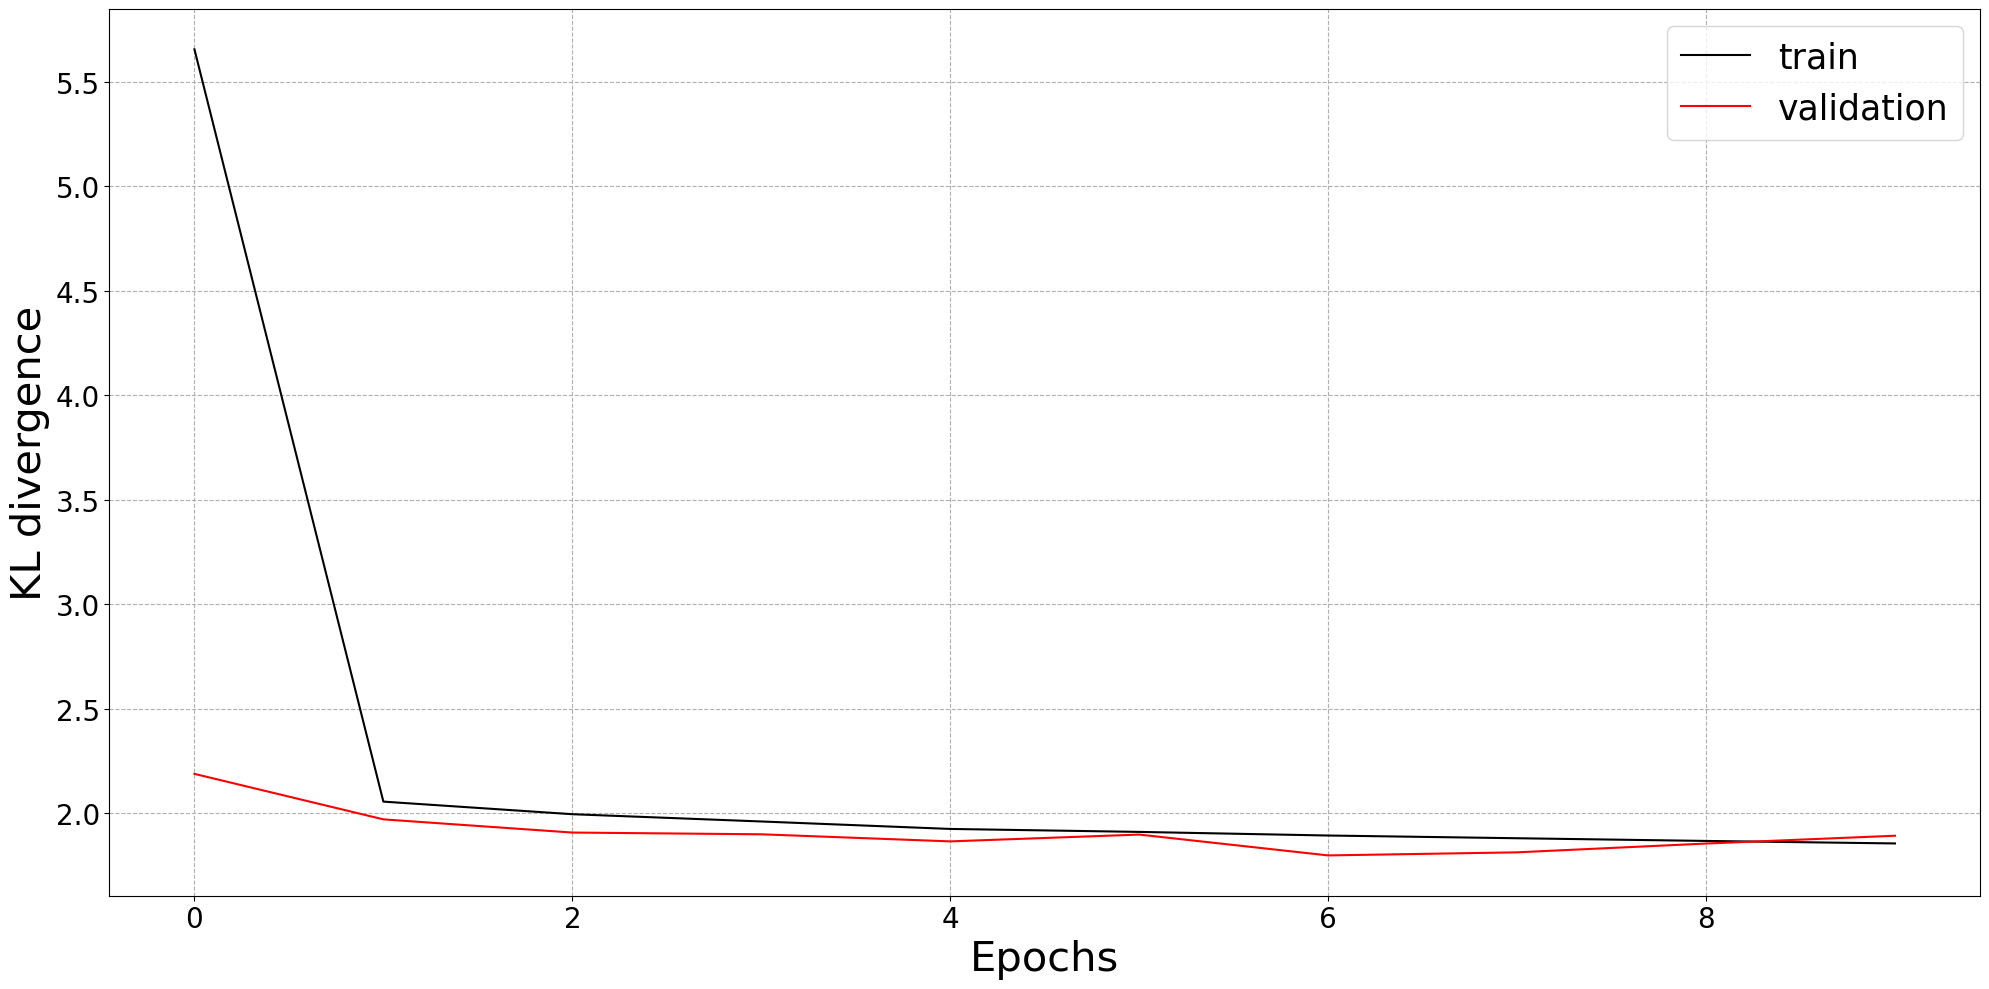

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (20, 10), tight_layout = True)
ax.plot(history.history['loss'], c = 'black', linewidth = 2, label = 'train', marker = 'o', ms = 15)
ax.plot(history.history['val_loss'], c = 'red', linewidth = 2, label = 'validation', marker = 'o', ms = 15)
ax.set_xlabel('Epochs', fontsize = 40)
ax.set_ylabel('KL divergence', fontsize = 40)
ax.grid(axis = 'both', linestyle = '--')
ax.tick_params(axis = 'both', labelsize = 25)
ax.legend(loc = 'upper right', fontsize = 30)
fig.savefig('traincurve.png', bbox_inches = 'tight')

### Test data

In [ ]:
Y_pred = model.predict(X_test_scaled)
print(Y_pred.shape)

cov_test = np.zeros((Y_pred.shape[0], 4, 4))
cov_pred = np.zeros((Y_pred.shape[0], 4, 4))
for i in tqdm(range(Y_pred.shape[0])):
    s_test = Y_test[i, :4]**2
    u_test = Y_test[i, 4:].reshape((4, 4))
    cov_test[i, :, :] = (u_test * s_test[None, :]) @ u_test.T
    s_pred = Y_pred[i, :4]**2
    u_pred = Y_pred[i, 4:].reshape((4, 4))
    cov_pred[i, :, :] = (u_pred * s_pred[None, :]) @ u_pred.T

(578095, 20)


### Results: Component-wise agreement

In [ ]:
def task_ndensity(i1, i2, cov_test = cov_test, cov_pred = cov_pred):
    x = cov_test[:, i1, i2]; xmin = np.min(x); xmax = np.max(x)
    y = cov_pred[:, i1, i2]; ymin = np.min(y); ymax = np.max(y)
    bins = np.linspace(min(xmin, ymin), max(xmax, ymax), 51)
    z = np.zeros((50, 50))
    for i in tqdm(range(50)):
        for j in range(50):
            if i != 50 and j != 50:
                index = np.where((y >= bins[i]) & (y < bins[i+1]) & (x >= bins[j]) & (x < bins[j+1]), True, False)
            elif i == 50 and j != 50:
                index = np.where((y >= bins[i]) & (y <= bins[i+1]) & (x >= bins[j]) & (x < bins[j+1]), True, False)
            elif i != 50 and j == 50:
                index = np.where((y >= bins[i]) & (y < bins[i+1]) & (x >= bins[j]) & (x <= bins[j+1]), True, False)
            else:
                index = np.where((y >= bins[i]) & (y <= bins[i+1]) & (x >= bins[j]) & (x <= bins[j+1]), True, False)
            z[i, j] = np.count_nonzero(index)
    return z, (bins[1:] + bins[:-1])*0.5

index_pair = [(0, 0), (0, 1), (0, 2), (0, 3),
              (1, 1), (1, 2), (1, 3),
              (2, 2), (2, 3),
              (3, 3)]
results = Parallel(n_jobs = 10)(
    delayed(task_ndensity)(*index_pair[i]) for i in range(10)
)
Z_ndensity = []
Z_axis = []
for z, z_axis in results:
    Z_ndensity.append(z)
    Z_axis.append(z_axis)

def task_statistic(i1, i2, cov_test = cov_test, cov_pred = cov_pred):
    x = cov_test[:, i1, i2]
    y = cov_pred[:, i1, i2]
    res = scipy.stats.pearsonr(x, y)
    return res.statistic

correlations = []
for i in range(10):
    correlations.append(task_statistic(*index_pair[i]))

index_invisible = [(1, 0),
                   (2, 0), (2, 1),
                   (3, 0), (3, 1), (3, 2)]

fig, ax = plt.subplots(4, 4, figsize = (45, 40), tight_layout = True)
for i in range(len(index_pair)):
    i1 = index_pair[i][0]
    i2 = index_pair[i][1]
    z_ndensity = Z_ndensity[i]
    z_axis = Z_axis[i]
    im = ax[i1, i2].pcolormesh(z_axis, z_axis, np.log10(z_ndensity))
    ax[i1, i2].plot(z_axis, z_axis, c = 'blue', linewidth = 3)
    ax[i1, i2].plot(z_axis, z_axis * correlations[i], c = 'red', linewidth = 3)
    ax[i1, i2].set_xlabel('Test ' +r'$[W^2m^{-4}]$', fontsize = 25, labelpad = 15)
    ax[i1, i2].set_ylabel('Predicted ' +r'$[W^2m^{-4}]$', fontsize = 25, labelpad = 15)
    ax[i1, i2].set_title('Element: {}, {}'.format(i1, i2), fontsize = 35, pad = 15, loc = 'left')
    ax[i1, i2].set_aspect('equal')
    ax[i1, i2].tick_params(axis = 'both', labelsize = 25)
    ax[i1, i2].text(z_axis[3], z_axis[45], 'R: {:.02f}'.format(correlations[i]), fontsize = 35)
    cbar = plt.colorbar(im, ax = ax[i1, i2], shrink = 0.7)
    cbar.ax.tick_params(axis = 'y', labelsize = 25)
    cbar.ax.set_title('logN', fontsize = 25, pad = 15)
for i in range(len(index_invisible)):
    i1 = index_invisible[i][0]
    i2 = index_invisible[i][1]
    ax[i1, i2].set_visible(False)
fig.savefig('scatter_covarianceelement.png', bbox_inches = 'tight')


### Results: Skill over a simple statistical baseline

In [ ]:
# Simple statistical model based on r_df threshold
swdr = sw_mean[0, :] + sw_mean[1, :]
swdf = sw_mean[2, :] + sw_mean[3, :]
rdf = swdf / (swdf + swdr)
rdf_train, rdf_test, _, _ = train_test_split(rdf, Y, test_size = 0.3, random_state=42)
# Training
params_bins = np.zeros((10, 20))
for i in range(10):
    if i == 9:
        index_bin = np.where((rdf_train >= 0.1*i) & (rdf_train <= 0.1*(i+1)), True, False)
    else:
        index_bin = np.where((rdf_train >= 0.1*i) & (rdf_train < 0.1*(i+1)), True, False)
    if np.any(index_bin):
        y_bin = tf.convert_to_tensor(Y_train[index_bin, :])
        u_bin, s_bin = vec_to_us(y_bin)
        u_bin = u_bin.numpy()
        s_bin = s_bin.numpy()
        cov_bin = np.mean((u_bin * s_bin[:, np.newaxis, :]) @ u_bin.transpose(0, 2, 1), axis = 0)
        u_bin, s_bin, _ = scipy.linalg.svd(cov_bin)
        params_bins[i, :] = np.concatenate((np.sqrt(s_bin), u_bin.flatten()), axis = 0)
# Prediction
Y_pred_st = np.zeros_like(Y_pred)
for i in range(10):
    if i == 9:
        index_bin = np.where((rdf_test >= 0.1*i) & (rdf_test <= 0.1*(i+1)), True, False)
    else:
        index_bin = np.where((rdf_test >= 0.1*i) & (rdf_test < 0.1*(i+1)), True, False)
    Y_pred_st[index_bin, :] = params_bins[i, :]

print(Y_pred.shape)
print(Y_pred_st.shape)


# Loss within each bin
loss_nn = []
loss_st = []
for i in range(10):
    if i == 9:
        index_bin = np.where((rdf_test >= 0.1*i) & (rdf_test <= 0.1*(i+1)), True, False)
    else:
        index_bin = np.where((rdf_test >= 0.1*i) & (rdf_test < 0.1*(i+1)), True, False)
    y_true = tf.convert_to_tensor(Y_test[index_bin, :])
    y_pred_nn = tf.convert_to_tensor(Y_pred[index_bin, :])
    y_pred_st = tf.convert_to_tensor(Y_pred_st[index_bin, :])
    u_true, s_true = vec_to_us(y_true)
    u_pred_nn, s_pred_nn = vec_to_us(y_pred_nn)
    u_pred_st, s_pred_st = vec_to_us(y_pred_st)

    # Log determinant: Determinants are simply product of singular values
    logdet = tf.math.log(tf.reduce_prod(s_true, axis = -1)).numpy()
    logdet_nn = tf.math.log(tf.reduce_prod(s_pred_nn, axis = -1)).numpy()
    logdet_st = tf.math.log(tf.reduce_prod(s_pred_st, axis = -1)).numpy()
    logdet_term_nn = logdet_nn - logdet
    logdet_term_st = logdet_st - logdet

    # Trace term: easy to compute inverse since we know orthogonal transformation
    S_nn_i = ((u_pred_nn * 1/s_pred_nn[:, None, :]) @ tf.transpose(u_pred_nn, perm = [0, 2, 1])).numpy()
    S_st_i = ((u_pred_st * 1/s_pred_st[:, None, :]) @ tf.transpose(u_pred_st, perm = [0, 2, 1])).numpy()
    S = ((u_true * s_true[:, None, :]) @ tf.transpose(u_true, perm = [0, 2, 1])).numpy()
    trace_term_nn = np.trace(S_nn_i @ S, axis1 = 1, axis2 = 2)
    trace_term_st = np.trace(S_st_i @ S, axis1 = 1, axis2 = 2)

    kl_nn = 0.5 * (trace_term_nn - k + logdet_term_nn)
    kl_st = 0.5 * (trace_term_st - k + logdet_term_st)
    loss_nn.append(kl_nn)
    loss_st.append(kl_st)

ticklabels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5',
              '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1']
n_sample_bin = [len(loss_nn[i]) for i in range(len(loss_nn))]

fig, ax = plt.subplots(1, 1, figsize = (20, 10))
ax2 = ax.twinx()
ax2.plot(np.arange(0, 10, 1), n_sample_bin, c = 'black', linewidth = 2, marker = 'o', ms = 20)
ax2.tick_params(axis = 'y', labelsize = 20)
ax2.set_ylabel('Number of samples', fontsize = 30, labelpad = 15)
bp1 = ax.boxplot(loss_nn, positions = np.arange(0, 10, 1)-0.15, widths = 0.2, showfliers=False, patch_artist=True, showmeans = True, meanline = True)
bp2 = ax.boxplot(loss_st, positions = np.arange(0, 10, 1)+0.15, widths = 0.2, showfliers=False, patch_artist=True, showmeans = True, meanline = True)
# 1. Customize Box Colors
for patch1, patch2 in zip(bp1['boxes'], bp2['boxes']):
    patch1.set_facecolor('Red')
    patch2.set_facecolor('Blue')
# 2. Customize Mean Bar Color
for mean1, mean2 in zip(bp1['means'], bp2['means']):
    mean1.set_color('white'); mean2.set_color('white')
    mean1.set_linestyle(':'); mean2.set_linestyle(':')
    mean1.set_linewidth(2); mean2.set_linewidth(2)
# 3. Customize Mean Bar Color
for median1, median2 in zip(bp1['medians'], bp2['medians']):
    median1.set_color('white'); median2.set_color('white')
    median1.set_linewidth(2); median2.set_linewidth(2)
bp1['boxes'][0].set_label('Neural Network')
bp2['boxes'][0].set_label('Simple Statistical')
ax.set_xlabel('Ratio of diffuse to net shortwave radiation', fontsize = 30, labelpad = 15)
ax.set_ylabel('KL loss', fontsize = 30, labelpad = 15)
ax.set_ylim([-0.5, 20])
ax.set_xticks(np.arange(0, 10, 1))
ax.set_xticklabels(ticklabels)
ax.tick_params(axis = 'both', labelsize = 20)
ax.grid(axis = 'y', linestyle = '--')
ax.legend(ncol = 2, loc = 'upper left', fontsize = 20)
fig.savefig('boxplot_baseline.png', bbox_inches = 'tight')


In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (12, 10), tight_layout = True)
im = ax.imshow(cov_pred[0, :, :], cmap = 'Reds')
ax.set_xticks([]); ax.set_yticks([])
cbar = plt.colorbar(im, shrink = 0.7)
cbar.ax.tick_params(axis = 'y', labelsize = 20)
cbar.ax.set_title(r'$[W^2m^{-4}]$', fontsize = 25)
fig.savefig('example_covariance.png', bbox_inches = 'tight')